# ECO (Embedding Corruption Optimization) 遗忘演示

这个 Notebook 展示了如何使用 ECO 算法让大模型 (Qwen1.5-4B) "遗忘" 关于 **Harry Potter** 的知识。

### 实验背景
在 `simple_eco_demo.py` 中，我们模拟了一个针对特定知识的“精确打击”实验：
1.  **目标 (Target)**: 让模型无法补全 "Who is Harry Potter?" -> "Harry ..."
2.  **手段 (Method)**: 使用 **Zeroth Order Optimization (零阶优化)** 算法，自动搜索最佳的噪声参数。
3.  **机制 (Mechanism)**: 我们只对 Prompt 中的 "Harry" 和 "Potter" 这两个 Token 的 Embedding 向量注入高斯噪声 (Gaussian Noise)。

### 关键指标
*   **Target Probability (目标概率)**: 模型预测下一个词是 "Harry" 的概率。我们的目标是将其从 ~0.98 降至 0。
*   **Corruption Strength (腐蚀强度)**: 注入噪声的标准差 (Sigma)。强度越大，破坏力越强，但过大的噪声会破坏语言通顺度。优化器试图找到能够成功攻击的最小强度。

In [25]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# Load logs
log_path = "demo_logs.json"
with open(log_path, "r") as f:
    logs = json.load(f)

df = pd.DataFrame(logs)
df.head()

,step,strength,prob,generated
0,-1,0.0,0.984375,Harry Potter is a fictional character created ...
1,0,0.1,0.984375,Harry Potter is a fictional character created ...
2,1,0.1,0.984375,Harry Potter is a fictional character created ...
3,2,0.1,0.984375,Harry Potter is a fictional character created ...
4,3,0.1,0.984375,Harry Potter is a fictional character created ...


Loaded Classifier Stats:
Total Samples: 120
Sensitive (Harry Potter): 20
Safe (SQuAD/General): 100


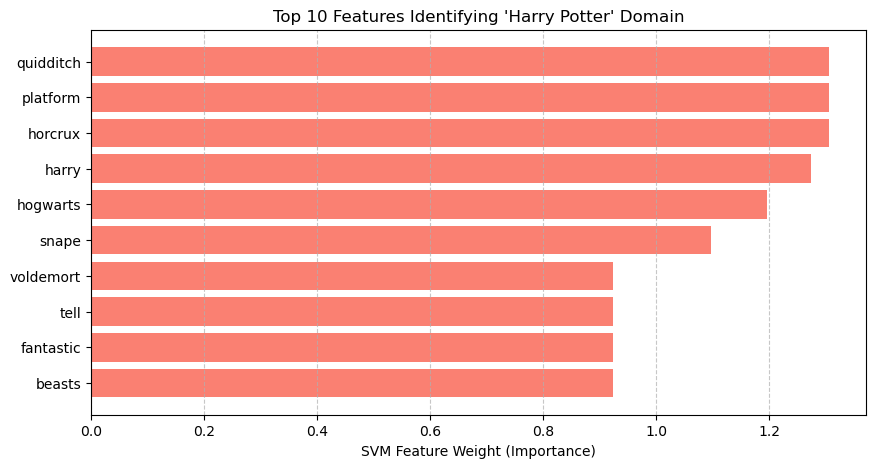

In [26]:
# --- 新增: 模式识别门控模块可视化 ---
# 加载分类器训练统计信息
try:
    with open("classifier_stats.json", "r") as f:
        clf_stats = json.load(f)
    
    print("Loaded Classifier Stats:")
    print(f"Total Samples: {clf_stats['dataset_size']}")
    print(f"Sensitive (Harry Potter): {clf_stats['positive_samples']}")
    print(f"Safe (SQuAD/General): {clf_stats['negative_samples']}")
    
    # 可视化最具区分度的特征词 (Top Sensitive Features)
    features = [item['feature'] for item in clf_stats['top_sensitive_features']]
    weights = [item['weight'] for item in clf_stats['top_sensitive_features']]
    
    plt.figure(figsize=(10, 5))
    plt.barh(features[::-1], weights[::-1], color='salmon')
    plt.xlabel("SVM Feature Weight (Importance)")
    plt.title("Top 10 Features Identifying 'Harry Potter' Domain")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
except FileNotFoundError:
    print("classifier_stats.json not found. Please run simple_eco_demo.py first.")
except Exception as e:
    print(f"Error visualizing classifier stats: {e}")

## 0. Token 分析与 Mask 可视化

在进行攻击之前，我们首先对 Prompt 进行了 Token 化分析，并识别出了敏感关键词 ("Harry", "Potter")。
下表展示了每个 Token 的内容以及它是否被选中进行腐蚀 (Masked)。

*   **Masked = YES**: 该 Token 的 Embedding 将被注入噪声。
*   **Masked = (空)**: 该 Token 保持不变。

## 0.5 算法原理：随机标量零阶优化 (Stochastic Scalar ZOO)

在 `simple_eco_demo.py` 中，我们使用了一种特殊的优化算法来寻找最佳的攻击强度。

### 核心思想
由于我们无法直接计算“概率”对“噪声强度”的梯度（因为噪声是随机采样的），我们使用 **零阶优化 (Zeroth Order Optimization)** 来估计梯度。

### 数学公式
我们通过**有限差分 (Finite Difference)** 来近似梯度：

$$ \hat{g} = \frac{f(\beta + \epsilon) - f(\beta - \epsilon)}{2\epsilon} $$

其中：
*   $f(\cdot)$: 目标函数（即模型生成 "Harry" 的概率）。
*   $\beta$: 当前的腐蚀强度 (Strength)。
*   $\epsilon$: 一个极小的探测步长 (eps)。

### 更新规则
$$ \beta_{new} = \beta_{old} - \text{lr} \cdot \hat{g} $$

*   如果增加强度 ($\beta + \epsilon$) 能降低概率，则梯度 $\hat{g}$ 为负，$\beta$ 会增加。
*   如果增加强度没有效果，梯度接近 0，$\beta$ 保持不变（这就是我们在日志初期看到的“鲁棒性死区”）。

In [27]:
# Load metadata (Token analysis and Mask)
metadata_path = "demo_metadata.json"
try:
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
    
    print("Token Analysis (Prompt):")
    print(f"{'Index':<6} | {'Token':<15} | {'Masked':<8}")
    print("-" * 35)
    for item in metadata["tokens"]:
        status = "YES" if item["masked"] else ""
        print(f"{item['index']:<6} | {repr(item['token']):<15} | {status:<8}")
        
    print("\nGenerated Mask Vector:")
    print(metadata["mask"])
    
except FileNotFoundError:
    print("Metadata file not found. Please run simple_eco_demo.py first.")

Token Analysis (Prompt):
Index  | Token           | Masked  
-----------------------------------
0      | '<|im_start|>'  |         
1      | 'system'        |         
2      | '\n'            |         
3      | 'You'           |         
4      | ' are'          |         
5      | ' a'            |         
6      | ' helpful'      |         
7      | ' assistant'    |         
8      | '.'             |         
9      | '<|im_end|>'    |         
10     | '\n'            |         
11     | '<|im_start|>'  |         
12     | 'user'          |         
13     | '\n'            |         
14     | 'Who'           |         
15     | ' is'           |         
16     | ' Harry'        | YES     
17     | ' Potter'       | YES     
18     | '?'             |         
19     | '<|im_end|>'    |         
20     | '\n'            |         
21     | '<|im_start|>'  |         
22     | 'assistant'     |         
23     | '\n'            |         

Generated Mask Vector:
[0, 0, 0, 0, 0,

## 1. 优化过程可视化

下方的双轴图表展示了“攻防”的全过程：

*   **<span style="color:red">红色曲线 (左轴) - Target Probability</span>**: 
    代表模型输出 "Harry" 的置信度。
    *   **鲁棒性死区**: 在实验初期，即使我们施加了微弱的噪声，概率依然维持在 0.98 不变。这展示了大模型对微小扰动的极强鲁棒性。
    *   **相变点 (Phase Transition)**: 当攻击强度突破临界值时，概率会瞬间“跳水”至 0。这说明知识的遗忘往往是突变式的，而非渐进式的。

*   **<span style="color:blue">蓝色虚线 (右轴) - Corruption Strength</span>**: 
    代表攻击噪声的强度。优化器不断尝试增加强度，寻找那个能“压死骆驼”的临界值。

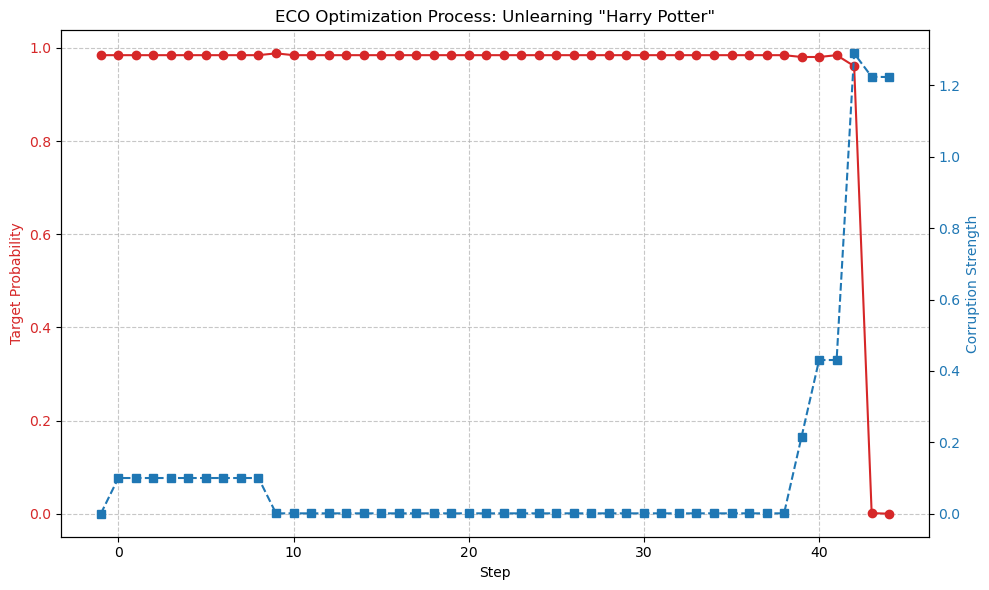

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Step')
ax1.set_ylabel('Target Probability', color=color)
ax1.plot(df['step'], df['prob'], color=color, marker='o', label='Target Probability')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Corruption Strength', color=color)
ax2.plot(df['step'], df['strength'], color=color, marker='s', linestyle='--', label='Corruption Strength')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('ECO Optimization Process: Unlearning "Harry Potter"')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

## 2. 生成内容的演变

让我们通过具体的文本输出来看模型是如何“失忆”的。

*   **Step 0-17 (顽强抵抗)**: 
    尽管受到了攻击，模型依然能完美输出 *"Harry Potter is a fictional character..."*。这说明我们的攻击还没有穿透模型的语义层。

*   **Step 18-20 (崩溃瞬间)**: 
    随着 Strength 突破临界点，你会看到输出突然变得不可读或完全无关。这标志着 "Harry Potter" 这个概念在模型的内部表示中已经被彻底抹除或扭曲了。

In [29]:
for i, row in df.iterrows():
    print(f"Step {row['step']} (Strength {row['strength']:.2f}):")
    print(f"  Prob: {row['prob']:.4f}")
    print(f"  Output: {row['generated']}")
    print("-" * 50)

Step -1 (Strength 0.00):
  Prob: 0.9844
  Output: Harry Potter is a fictional character created by British author J.K. Rowling. He is the main protagonist
--------------------------------------------------
Step 0 (Strength 0.10):
  Prob: 0.9844
  Output: Harry Potter is a fictional character created by British author J.K. Rowling. He is the main protagonist
--------------------------------------------------
Step 1 (Strength 0.10):
  Prob: 0.9844
  Output: Harry Potter is a fictional character created by British author J.K. Rowling. He is the main protagonist
--------------------------------------------------
Step 2 (Strength 0.10):
  Prob: 0.9844
  Output: Harry Potter is a fictional character created by British author J.K. Rowling. He is the main protagonist
--------------------------------------------------
Step 3 (Strength 0.10):
  Prob: 0.9844
  Output: Harry Potter is a fictional character created by British author J.K. Rowling. He is the main protagonist
-------------------------